Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#2e3140",
    "axes.labelcolor":  "#c9d1e0",
    "xtick.color":      "#c9d1e0",
    "ytick.color":      "#c9d1e0",
    "text.color":       "#c9d1e0",
    "grid.color":       "#2e3140",
    "grid.linestyle":   "--",
    "font.family":      "monospace",
})
ACCENT   = "#00e5ff"
WARN     = "#ff6b6b"
NEUTRAL  = "#7c83fd"

Loading Data

In [4]:
import kagglehub
from kagglehub import KaggleDatasetAdapter


In [52]:
dataset_id = "vijayuv/onlineretail"
download_path = kagglehub.dataset_download(dataset_id)

df = pd.read_csv(f"{download_path}/OnlineRetail.csv", encoding='ISO-8859-1')



Using Colab cache for faster access to the 'onlineretail' dataset.


In [6]:
print(f"Dataset shape: {df.shape}")
print("--------------------------------------------------------------------------------------------------\n")
print(f"Dataset columns: {df.columns}")
print("--------------------------------------------------------------------------------------------------\n")
print(df.head())
print("--------------------------------------------------------------------------------------------------\n")
df.info()
print("--------------------------------------------------------------------------------------------------\n")

Dataset shape: (541909, 8)
--------------------------------------------------------------------------------------------------

Dataset columns: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
--------------------------------------------------------------------------------------------------

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  

#Data Cleaning

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64
CustomerID    24.926694
dtype: float64


Text(0.5, 1.0, 'Columns with >10% Missing Values')

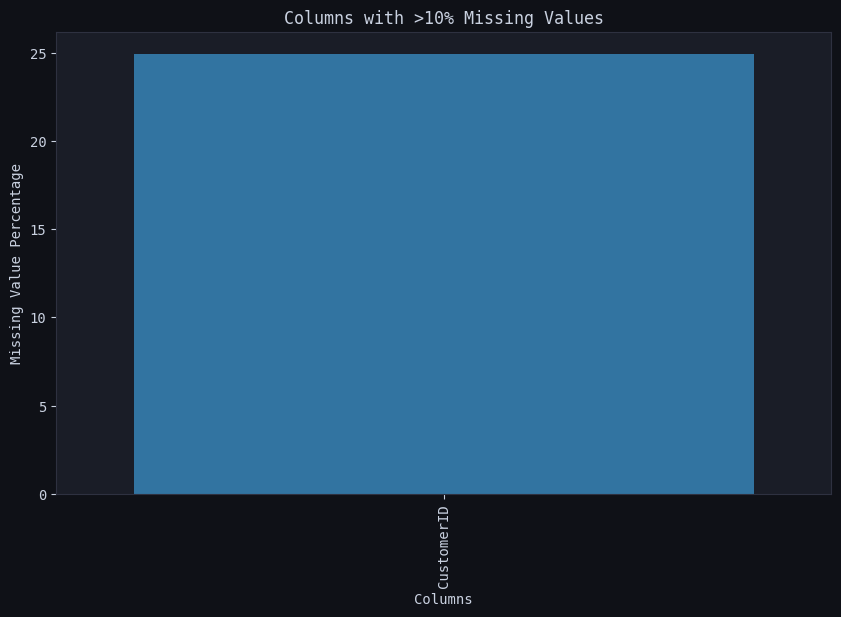

In [53]:
#1. Calculate missing value count for each column
#2. calculate missing value percentage for each column
#3. identify wich columns have >10% missing values
#4. create a bar chart showing missing % by column
#1.
missing_value_counts = df.isnull().sum()
print(missing_value_counts)

#2

missing_value_percentage = df.isnull().sum() / len(df) * 100
print(missing_value_percentage)

#3.

columns_with_high_missing = missing_value_percentage[missing_value_percentage > 10].sort_values(ascending=False)
print(columns_with_high_missing)

#4.
plt.figure(figsize=(10,6))
sns.barplot(x=columns_with_high_missing.index, y=columns_with_high_missing.values)
plt.xticks(rotation=90)
plt.xlabel('Columns')
plt.ylabel('Missing Value Percentage')
plt.title('Columns with >10% Missing Values')

Duplicates and Outliers

In [54]:
#1. count total duplicate rows
#2. count duplicate transactions(same OrderID)
#3. Identify obvious outliers:- negative quatities(returns/cancellations), negative prices, zero or null prices
#4. Display statistics(min,max,mean,median) for numeric columns

#1.
duplicate_rows = df[df.duplicated()]
print(f"Total duplicate rows: {len(duplicate_rows)}")

#2.
duplicate_transactions = df[df.duplicated(subset='InvoiceNo', keep=False)]
print(f"Duplicate transactions: {len(duplicate_transactions)}")

#3.
negative_quantities = df[df['Quantity'] < 0]
print(f"Negative quantities: {len(negative_quantities)}")
negative_prices = df[df['UnitPrice'] < 0]
print(f"Negative prices: {len(negative_prices)}")
zero_or_null_prices = df[df['UnitPrice'].isin([0, np.nan])]
print(f"Zero or null prices: {len(zero_or_null_prices)}")

#4.
df.describe()
df.dtypes




Total duplicate rows: 5268
Duplicate transactions: 536068
Negative quantities: 10624
Negative prices: 2
Zero or null prices: 2515


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


Data Quality Summary

In [9]:
#1. create a summary table: Column| Missing%|DataType|Issue
#2. Data cleaning strategy: drop rows with missing critical fields, handle negative quantities, remove duplicates
#3. Apply cleaning

#1. summary table
summary_table = pd.DataFrame({
    'Column': df.columns,
    'Missing %': missing_value_percentage,
    'DataType': df.dtypes,
    'Issue': ['Critical' if x > 10 else 'None' for x in missing_value_percentage]
})
print(summary_table)

#2.
#drop rows with missing critical fields
df = df.dropna(subset=['Description', 'CustomerID'])

#handle negative quantities
df = df[(df['Quantity'] >= 0) & (df['UnitPrice'] >= 0)]

#remove duplicates
df = df.drop_duplicates()

                  Column  Missing % DataType     Issue
InvoiceNo      InvoiceNo   0.000000   object      None
StockCode      StockCode   0.000000   object      None
Description  Description   0.268311   object      None
Quantity        Quantity   0.000000    int64      None
InvoiceDate  InvoiceDate   0.000000   object      None
UnitPrice      UnitPrice   0.000000  float64      None
CustomerID    CustomerID  24.926694  float64  Critical
Country          Country   0.000000   object      None


In [10]:
print(f"Shape of the cleaned DataFrame: {df.shape}")

Shape of the cleaned DataFrame: (392732, 8)


#What data quality issues have been fixed?

1. Missing Values: Dropped rows with missing CustomerID (critical for customer-centric analysis) and Description to ensure data integrity.

2. Invalid Numeric Values: Removed rows with negative quantities (returns/cancellations), negative prices, and zero prices to focus on valid sales transactions.

3. Duplicate Rows: Eliminated 5,268 exact duplicate rows to prevent overcounting and ensure unique transaction records.



Customer Segmentation via RFM(Recency, Frequency, Monetary)

**RFM:**
1. **Recency (R):** Days since last purchase(lower is better)
2. **Frequency (F)**: Number of purchases(higher is better)
3. **Monetory (M)**: Total money spent(higher is better)

1. **Recency (R)**

In [11]:
#Calculate RFM Metrics
#1. Set a reference date(use max date in dataset +1day)
#2. For each unique customer: R:Calculate days between their last purchase and reference date. F:calculate total number of purchases(transactions). M: Sum of all money spent(Quantity x price)
#3. create RFM dataframe with columns: customerid, recency, frequency, monetory

# Converting 'InvoiceDate' to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#1.
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

#2.
recency_df = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days
}).rename(columns={'InvoiceDate': 'Recency'})
print(recency_df)


            Recency
CustomerID         
12346.0         326
12347.0           2
12348.0          75
12349.0          19
12350.0         310
...             ...
18280.0         278
18281.0         181
18282.0           8
18283.0           4
18287.0          43

[4339 rows x 1 columns]


2. **Frequency**

In [12]:
frequency_df = df.groupby('CustomerID').agg(
    Frequency=('InvoiceNo', 'nunique')
)
print(frequency_df.head())

            Frequency
CustomerID           
12346.0             1
12347.0             7
12348.0             4
12349.0             1
12350.0             1


3. **Monetary**

In [13]:
# Calculate TotalSum for Monetary calculation
df['TotalSum'] = df['Quantity'] * df['UnitPrice']
print(df.head())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  TotalSum  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom     15.30  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom     20.34  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom     22.00  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom     20.34  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom     20.34  


In [14]:
# 2. Aggregate Data (RFM Table)
print("RFM Table\n")
print("============")
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days, # Recency
    'InvoiceNo': 'count',                                    # Frequency
    'TotalSum': 'sum'                                        # Monetary
})
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'InvoiceNo': 'Frequency',
                    'TotalSum': 'Monetary'}, inplace=True)

# 3. Calculate RFM Scores (1-5, lower recency is better)
rfm["R"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])
print(rfm.head())
print("-------------------------------------------------------""\n")
# 4. Create Combined RFM Score
print("Combined RFM Score\n")
print("====================")
rfm["RFM_Score"] = rfm["R"].astype(str) + rfm["F"].astype(str) + rfm["M"].astype(str)

print(rfm.head())

RFM Table

            Recency  Frequency  Monetary  R  F  M
CustomerID                                       
12346.0         326          1  77183.60  1  1  5
12347.0           2        182   4310.00  5  5  5
12348.0          75         31   1797.24  2  3  4
12349.0          19         73   1757.55  4  4  4
12350.0         310         17    334.40  1  2  2
-------------------------------------------------------

Combined RFM Score

            Recency  Frequency  Monetary  R  F  M RFM_Score
CustomerID                                                 
12346.0         326          1  77183.60  1  1  5       115
12347.0           2        182   4310.00  5  5  5       555
12348.0          75         31   1797.24  2  3  4       234
12349.0          19         73   1757.55  4  4  4       444
12350.0         310         17    334.40  1  2  2       122


In [15]:
# 1. Average Recency, Frequency, and Monetary value
print("Average Recency: ", rfm['Recency'].mean())
print("Average Frequency: ", rfm['Frequency'].mean())
print("Average Monetary: ", rfm['Monetary'].mean())

Average Recency:  92.51832219405392
Average Frequency:  90.51209956211109
Average Monetary:  2048.21592394561


### Distribution of RFM Scores

In [16]:
# 2. Distribution of RFM scores
rfm_score_counts = rfm['RFM_Score'].value_counts().sort_index()
print("RFM Score Distribution:\n", rfm_score_counts)

RFM Score Distribution:
 RFM_Score
111    255
112     66
113     22
114      8
115      5
      ... 
545     65
552      1
553     24
554     69
555    309
Name: count, Length: 118, dtype: int64


1. **Average Recency:** Average number of days since a customer's last purchase is approximately **92.52 days**
2. **Average Frequency:** Customers on average, made approximately **90.51 purchases**
3. **Average Monetary value:** Average total money spent by customers is approximately **£2048.22.**

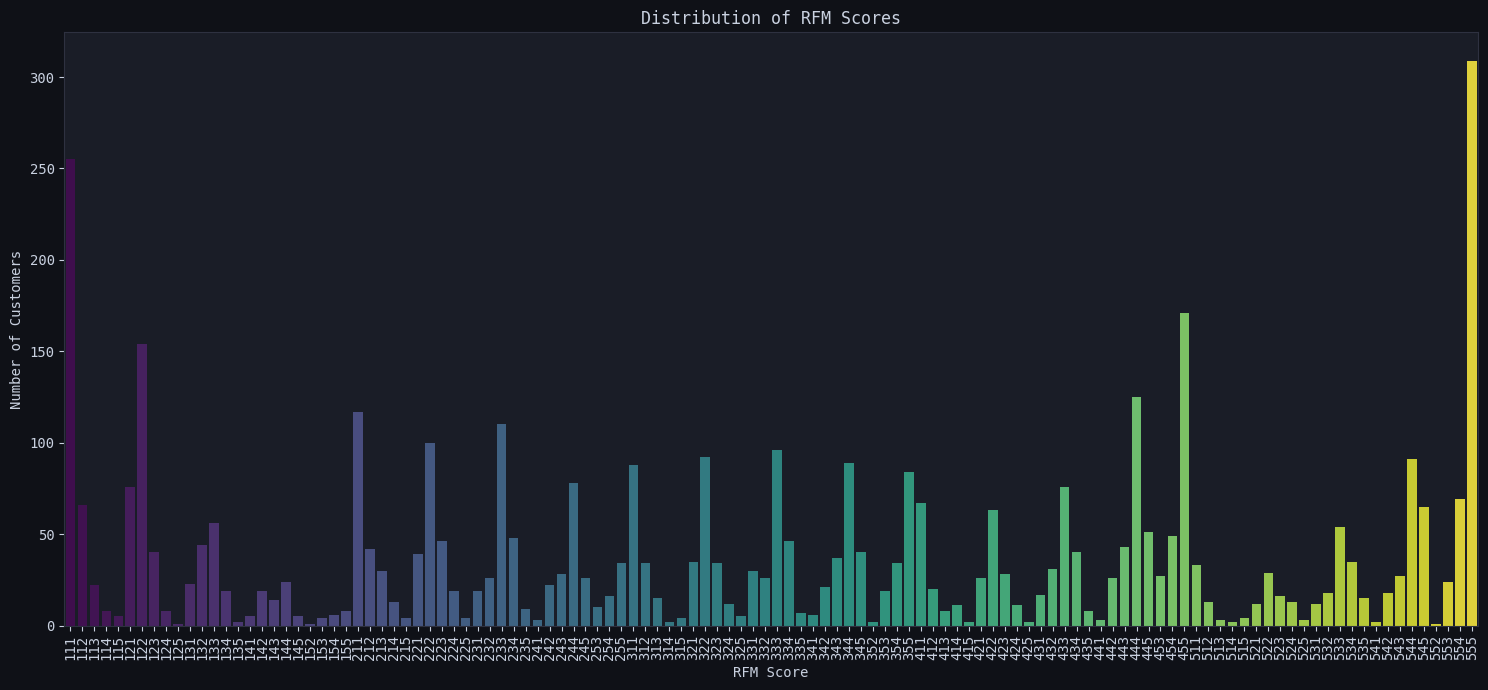

In [17]:
plt.figure(figsize=(15, 7))
sns.barplot(x=rfm_score_counts.index, y=rfm_score_counts.values, palette='viridis')
plt.title('Distribution of RFM Scores')
plt.xlabel('RFM Score')
plt.ylabel('Number of Customers')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [18]:
# Number of top-tier customers (RFM Score '555')
top_tier_customers = rfm[rfm['RFM_Score'] == '555']
print(f"Number of Top-Tier Customers (RFM 555): {len(top_tier_customers)}")

Number of Top-Tier Customers (RFM 555): 309


Customer Segmentation

In [19]:
#1.define segments based on rfm score: Champions: score 11-12(spend most, buy often,bought recently), loyal customer: score 9-10, at risk: score 5-6, lost:score 0-4
#2. create a segment column with above categories
#3. calculate segment statistics: count of customers per segment, avg sepending per segment, avg frequency per segment
#4. avg frequency per segment

In [20]:
def rfm_level(df):
    if (df['R'] >= 4) and (df['F'] >= 4) and (df['M'] >= 4):
        return 'Champions'
    elif (df['R'] >= 3) and (df['F'] >= 3) and (df['M'] >= 3):
        return 'Loyal Customers'
    elif (df['R'] >= 2) and (df['F'] >= 2):
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(rfm_level, axis=1)
display(rfm.head())

,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,5,115,Lost Customers
12347.0,2,182,4310.00,5,5,5,555,Champions
12348.0,75,31,1797.24,2,3,4,234,At Risk
12349.0,19,73,1757.55,4,4,4,444,Champions
12350.0,310,17,334.40,1,2,2,122,Lost Customers


Segment statistics

In [21]:
segment_stats = rfm.groupby('Segment').agg(
    Customer_Count=('Recency', 'count'),
    Average_Monetary=('Monetary', 'mean'),
    Average_Frequency=('Frequency', 'mean'),
    Average_Recency=('Recency', 'mean')
).reset_index()

display(segment_stats)

,Segment,Customer_Count,Average_Monetary,Average_Frequency,Average_Recency
0,At Risk,1231,782.591935,46.482535,75.402112
1,Champions,930,6085.864161,255.841935,13.044086
2,Lost Customers,1377,683.378802,18.719680,194.434277
3,Loyal Customers,801,1651.650363,89.640449,35.892634


To visualize the distribution of these segments, a bar chart can be helpful.

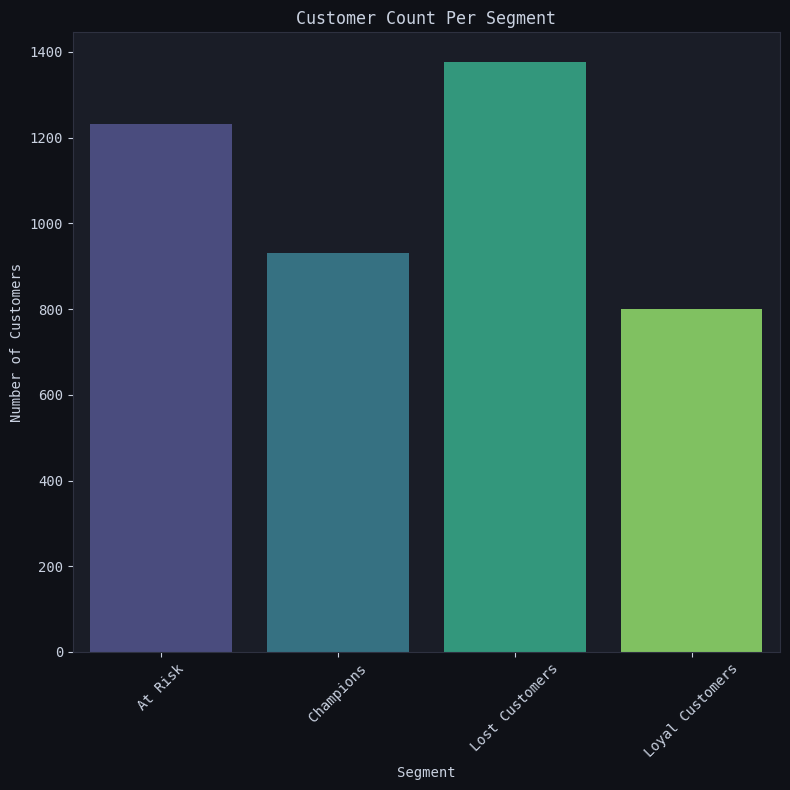

In [55]:
plt.figure(figsize=(8,8))
sns.barplot(x='Segment', y='Customer_Count', data=segment_stats, palette='viridis')
plt.title('Customer Count Per Segment')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

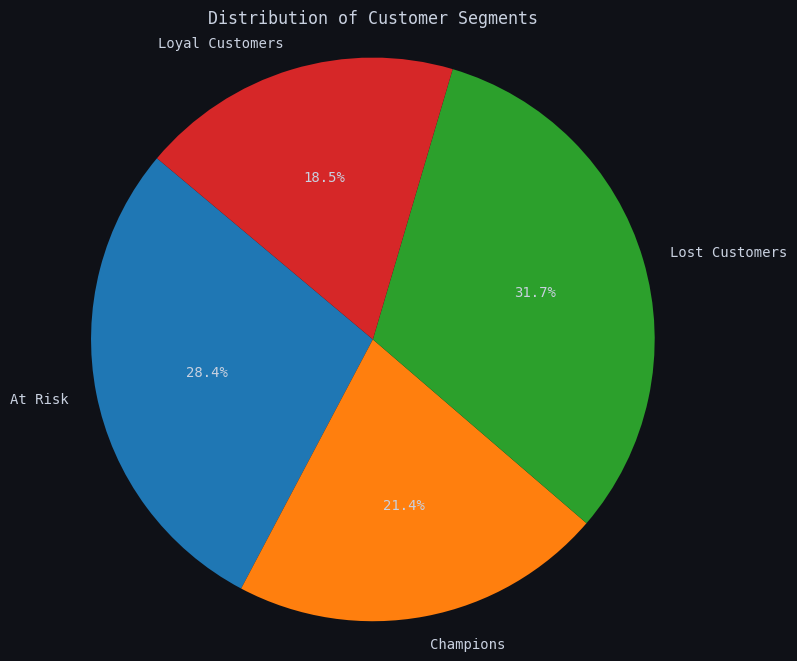

In [56]:
#pie chart: % of customers in each segment
plt.figure(figsize=(8, 8))
plt.pie(segment_stats['Customer_Count'], labels=segment_stats['Segment'], autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Customer Segments')
plt.axis('equal')
plt.show()


What percent of customers are Champions vs At Risk?
1. Champions: 21.4%
2. At Risk: 28.4%

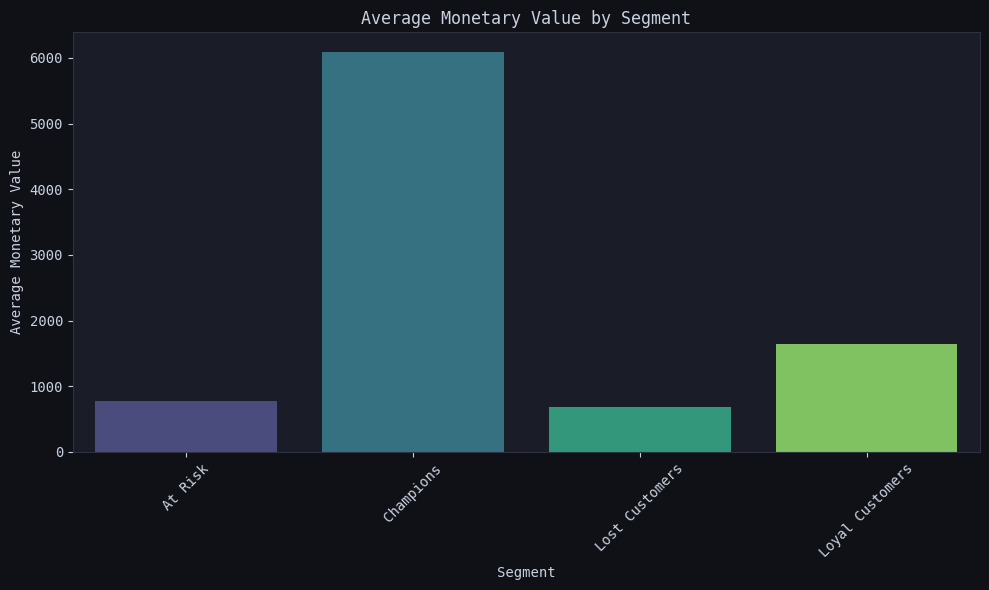

In [24]:
#bar chart: Average monetary value by segment
plt.figure(figsize=(10,6))
sns.barplot(x='Segment', y='Average_Monetary', data=segment_stats, palette='viridis')
plt.title('Average Monetary Value by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Monetary Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

RFM Scatter Plot

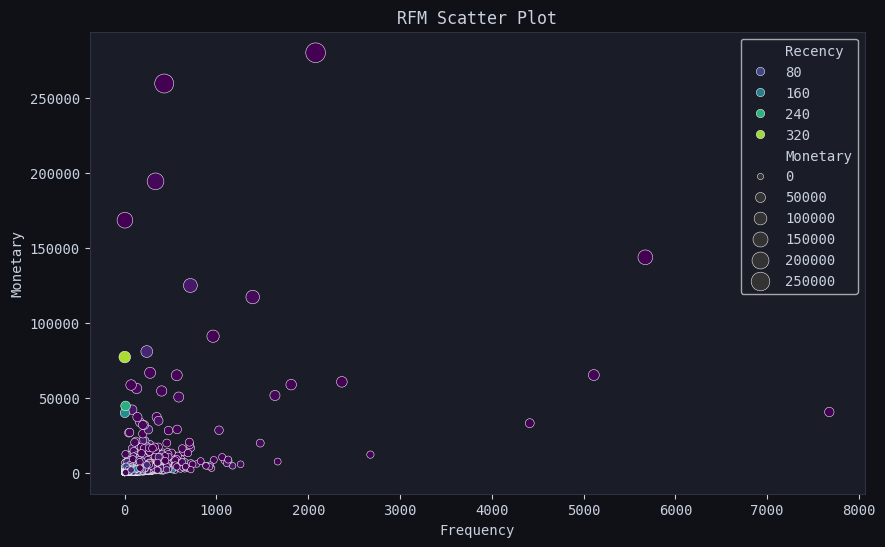

In [58]:
#1. Create a scatter plot: X axis frequency, y axis monetary, color: recency(use colormap) size: total purchases
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Recency', size='Monetary', sizes=(20, 200), palette='viridis')
plt.title('RFM Scatter Plot')
plt.xlabel('Frequency')
plt.ylabel('Monetary')

plt.show()

#Purchase Behavior Pattern
###Product Analysis

In [26]:
#1. Group by product(Description column)
#2. for each product, calculate: total revenue,(quantity x price summed), total quantity sold, number of transactions, avg price per unit
#3. sort revenue(descending)
#4. display top 10 products by revenue
#5. create a bar chart: top 10 products by revenue
#1.
df['TotalSum'] = df['Quantity'] * df['UnitPrice']
product_group = df.groupby('Description').agg({
    'TotalSum': 'sum',
    'Quantity': 'sum',
    'InvoiceNo': 'nunique',
    'UnitPrice': 'mean'
}).reset_index()
product_group.rename(columns={'InvoiceNo': 'Transactions', 'UnitPrice': 'AvgPrice'}, inplace=True)
print("\nProduct Group Aggregations (Initial):")
display(product_group.head())
print("---------------------------------------------------------------------------------------------\n")
# 2.
product_group['TotalRevenue'] = product_group['TotalSum']
product_group.drop(columns=['TotalSum'], inplace=True)
print("\nProduct Group with Total Revenue:")
display(product_group.head())
print("---------------------------------------------------------------------------------------------\n")
#3.
product_group = product_group.sort_values(by='TotalRevenue', ascending=False)
print("\nProduct Group Sorted by Total Revenue:")
display(product_group.head())
print("---------------------------------------------------------------------------------------------\n")
#4.
top_10_pdts = product_group.head(10)
print("\nTop 10 Products by Revenue:")
print(top_10_pdts)




Product Group Aggregations (Initial):


,Description,TotalSum,Quantity,Transactions,AvgPrice
0,4 PURPLE FLOCK DINNER CANDLES,265.66,138,36,2.312162
1,50'S CHRISTMAS GIFT BAG LARGE,2272.25,1885,109,1.248073
2,DOLLY GIRL BEAKER,2754.50,2394,133,1.243704
3,I LOVE LONDON MINI BACKPACK,1449.85,359,68,4.138406
4,I LOVE LONDON MINI RUCKSACK,4.15,1,1,4.150000


---------------------------------------------------------------------------------------------


Product Group with Total Revenue:


,Description,Quantity,Transactions,AvgPrice,TotalRevenue
0,4 PURPLE FLOCK DINNER CANDLES,138,36,2.312162,265.66
1,50'S CHRISTMAS GIFT BAG LARGE,1885,109,1.248073,2272.25
2,DOLLY GIRL BEAKER,2394,133,1.243704,2754.50
3,I LOVE LONDON MINI BACKPACK,359,68,4.138406,1449.85
4,I LOVE LONDON MINI RUCKSACK,1,1,4.150000,4.15


---------------------------------------------------------------------------------------------


Product Group Sorted by Total Revenue:


,Description,Quantity,Transactions,AvgPrice,TotalRevenue
2319,"PAPER CRAFT , LITTLE BIRDIE",80995,1,2.080000,168469.60
2767,REGENCY CAKESTAND 3 TIER,12384,1704,12.475613,142264.75
3698,WHITE HANGING HEART T-LIGHT HOLDER,36706,1971,2.892768,100392.10
1762,JUMBO BAG RED RETROSPOT,46078,1600,2.015969,85040.54
1992,MEDIUM CERAMIC TOP STORAGE JAR,77916,195,1.220303,81416.73


---------------------------------------------------------------------------------------------


Top 10 Products by Revenue:
                             Description  Quantity  Transactions    AvgPrice  \
2319         PAPER CRAFT , LITTLE BIRDIE     80995             1    2.080000   
2767            REGENCY CAKESTAND 3 TIER     12384          1704   12.475613   
3698  WHITE HANGING HEART T-LIGHT HOLDER     36706          1971    2.892768   
1762             JUMBO BAG RED RETROSPOT     46078          1600    2.015969   
1992      MEDIUM CERAMIC TOP STORAGE JAR     77916           195    1.220303   
2611                             POSTAGE      3120          1099   31.570482   
2345                       PARTY BUNTING     15283          1380    4.872712   
216        ASSORTED COLOUR BIRD ORNAMENT     35263          1375    1.680710   
2130                              Manual      6939           258  174.650211   
2656                  RABBIT NIGHT LIGHT     27153           801    2.012770

What are the top revenue generating products?

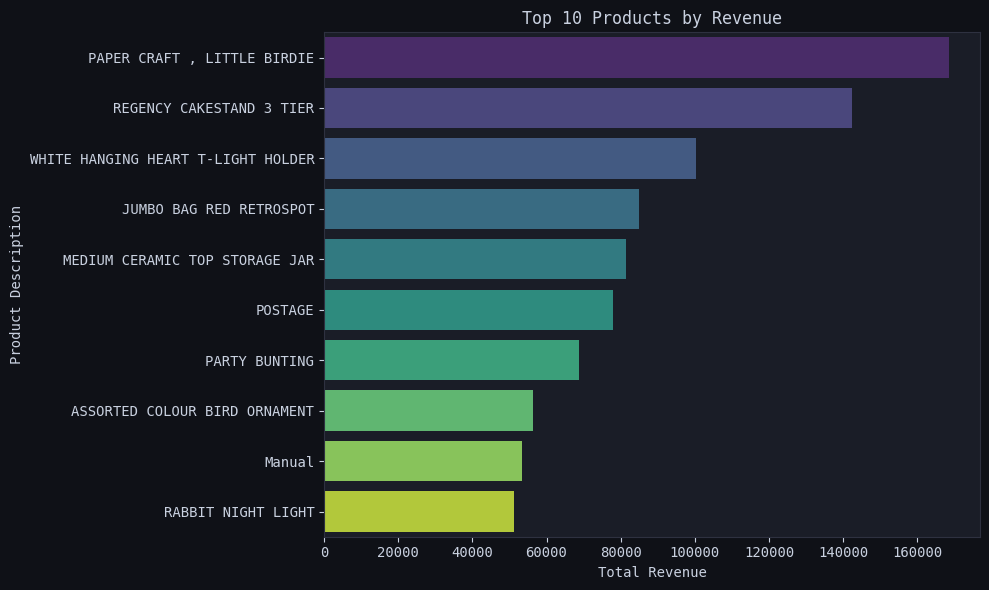

In [27]:
plt.figure(figsize=(10,6))
sns.barplot(x='TotalRevenue', y='Description', data=top_10_pdts, palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

Frequency Distribution

In [28]:
#1. for each customer count total transaction
total_transactions = df.groupby('CustomerID').agg({'InvoiceNo': 'nunique'}).reset_index()
total_transactions.rename(columns={'InvoiceNo': 'TotalTransactions'}, inplace=True)
display(total_transactions.head())

,CustomerID,TotalTransactions
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


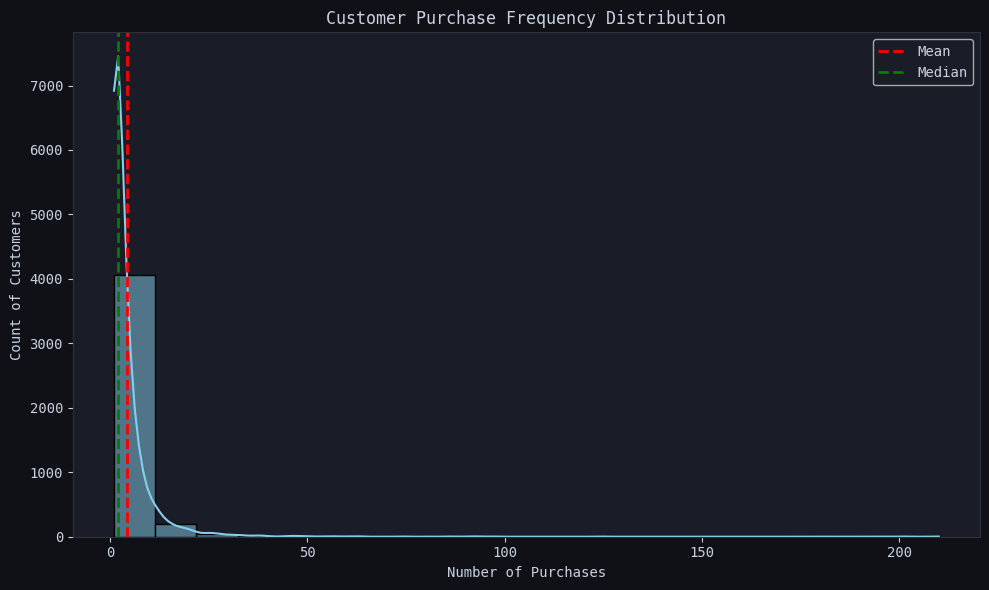

In [29]:
#2. create histogram: customer purchase frequency x-axis: number of purchases, y-axis count of customers, add median and mean lines
plt.figure(figsize=(10,6))
sns.histplot(data = total_transactions, x='TotalTransactions', bins=20, kde=True, color='skyblue')
plt.axvline(total_transactions['TotalTransactions'].mean(), color='red', linestyle='dashed', linewidth= 2, label='Mean')
plt.axvline(total_transactions['TotalTransactions'].median(), color='green', linestyle='dashed', linewidth= 2, label='Median')
plt.title('Customer Purchase Frequency Distribution')
plt.xlabel('Number of Purchases')
plt.ylabel('Count of Customers')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
#3. calculate statistics:
#a. what % buy only once?
#b. what % buy more than 5 times
#c. avg purchases per customer

#a.
one_time_buyers = total_transactions[total_transactions['TotalTransactions'] == 1]
print("\n" + "="*80)
print(f"Percentage of customers who bought only once: {len(one_time_buyers) / len(total_transactions) * 100:.2f}%")
print("="*80)

#print("---------------------------\n")
#b.
frequent_buyers = total_transactions[total_transactions['TotalTransactions'] > 5]
print("\n" + "="*80)
print(f"Percentage of customers who bought more than 5 times: {len(frequent_buyers) / len(total_transactions) * 100:.2f}%")
print("="*80)
#print("---------------------------\n")
#c.
avg_purchases_per_customer = total_transactions['TotalTransactions'].mean()
print("\n" + "="*80)
print(f"Average purchases per customer: {avg_purchases_per_customer:.2f}")
print("="*80)

print("\n" + "="*45)
print("Our customer base is mostly one-time buyers")
print("="*45)




Percentage of customers who bought only once: 34.43%

Percentage of customers who bought more than 5 times: 20.10%

Average purchases per customer: 4.27

Our customer base is mostly one-time buyers


Order Value Trend

In [31]:
#1. calculate order value(transaction total=quantity * price)
#2. Extract date from InvoiceDate
#3. Group by date(daily or weekly)
#4. Calculte: avg order value by time period, total revenue by time period, number of orders by time period


df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#1.
df['OrderValue'] = df['Quantity'] * df['UnitPrice']

#2.
df['Date'] = df['InvoiceDate'].dt.date

#3
daily_order_value = df.groupby('Date')['OrderValue'].sum()
weekly_order_value = df.groupby(pd.Grouper(key='InvoiceDate', freq='W'))['OrderValue'].sum()

print("\n--- Daily Order Value (First 5 entries) ---")
print(daily_order_value.head().apply(lambda x: f'£{x:,.2f}'))
print(f"Total Sum of Daily Order Values: £{daily_order_value.sum():,.2f}")

print("\n--- Weekly Order Value (First 5 entries) ---")
print(weekly_order_value.head().apply(lambda x: f'£{x:,.2f}'))
print(f"Total Sum of Weekly Order Values: £{weekly_order_value.sum():,.2f}")

#4. avg order value by time period
print("\n--- Average Order Value by Time Period ---")
print(f"Daily Average Order Value: £{daily_order_value.mean():,.2f}")
print(f"Weekly Average Order Value: £{weekly_order_value.mean():,.2f}")

#total revenue by time period
print("\n--- Total Revenue Across All Periods ---")
print(f"Total Revenue: £{df['OrderValue'].sum():,.2f}")

#number of orders by time period
print("\n--- Number of Orders by Time Period ---")
print(f"Daily Number of Orders: {df['Date'].nunique():,}")
print(f"Weekly Number of Orders: {df.groupby(pd.Grouper(key='InvoiceDate', freq='W'))['InvoiceNo'].nunique().sum():,}")


--- Daily Order Value (First 5 entries) ---
Date
2010-12-01    £46,192.49
2010-12-02    £47,197.57
2010-12-03    £23,876.63
2010-12-05    £31,361.28
2010-12-06    £31,009.33
Name: OrderValue, dtype: object
Total Sum of Daily Order Values: £8,887,208.89

--- Weekly Order Value (First 5 entries) ---
InvoiceDate
2010-12-05    £148,627.97
2010-12-12    £212,619.13
2010-12-19    £163,116.12
2010-12-26     £46,059.51
2011-01-02          £0.00
Freq: W-SUN, Name: OrderValue, dtype: object
Total Sum of Weekly Order Values: £8,887,208.89

--- Average Order Value by Time Period ---
Daily Average Order Value: £29,138.39
Weekly Average Order Value: £164,577.94

--- Total Revenue Across All Periods ---
Total Revenue: £8,887,208.89

--- Number of Orders by Time Period ---
Daily Number of Orders: 305
Weekly Number of Orders: 18,536


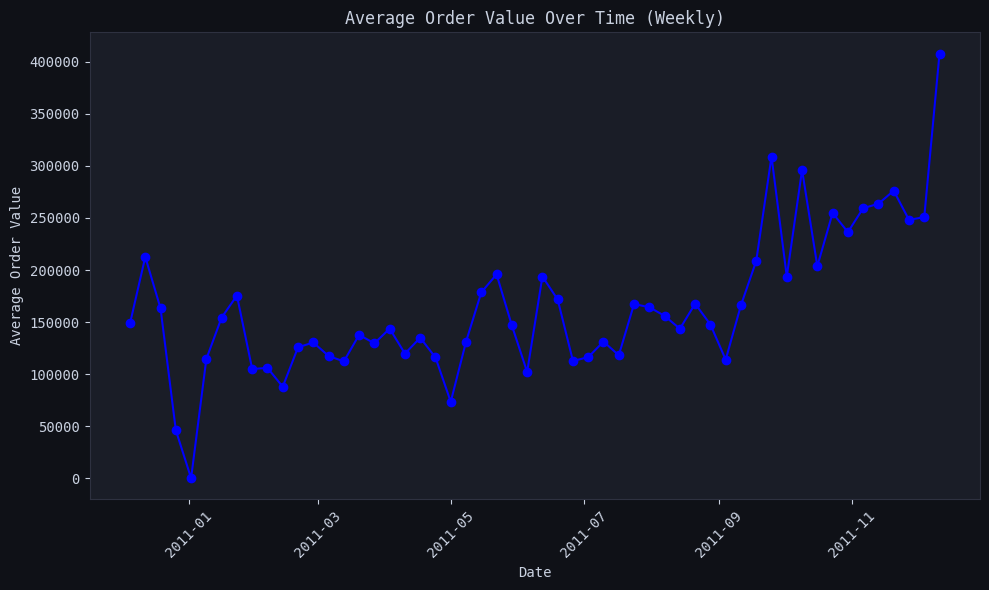

In [32]:
#Create a line plot: average order value over time
#weekly
plt.figure(figsize=(10,6))
plt.plot(weekly_order_value.index, weekly_order_value.values, marker='o', linestyle='-', color='b')
plt.title('Average Order Value Over Time (Weekly)')
plt.xlabel('Date')
plt.ylabel('Average Order Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

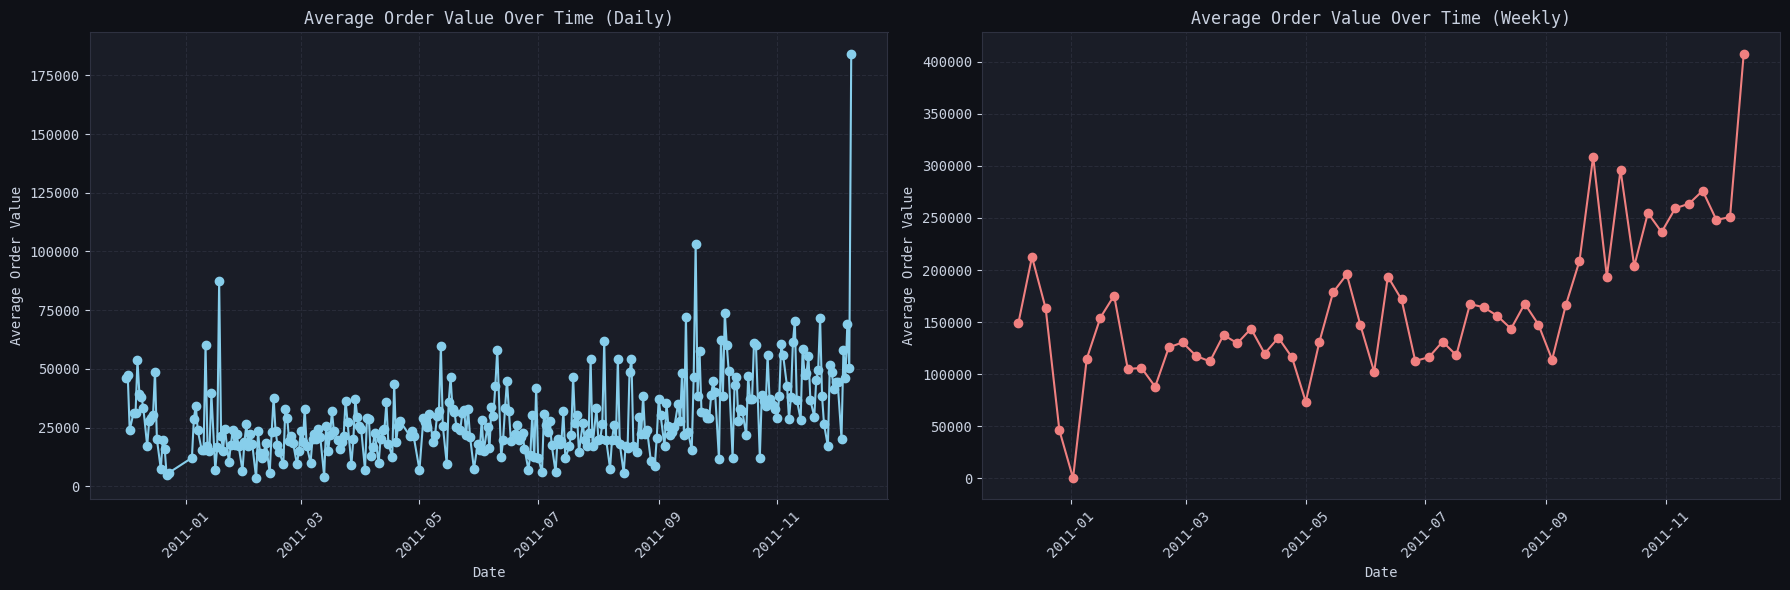

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Daily Order Value Plot
axes[0].plot(daily_order_value.index, daily_order_value.values, marker='o', linestyle='-', color='skyblue')
axes[0].set_title('Average Order Value Over Time (Daily)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Average Order Value')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Weekly Order Value Plot
axes[1].plot(weekly_order_value.index, weekly_order_value.values, marker='o', linestyle='-', color='lightcoral')
axes[1].set_title('Average Order Value Over Time (Weekly)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Order Value')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Is Average Order Value(AOV) increasing, decreasing, or stable over time?

Based on the daily and weekly Average Order Value (AOV) plots, it appears that the AOV over time is **stable but with noticeable fluctuations**. There isn't a clear, consistent increasing or decreasing trend over the entire period displayed. We can observe peaks and troughs, indicating variability in daily and weekly AOV, but the overall average seems to remain within a certain range.

Seasonal Patterns

In [34]:
#extract month from date

df['Month'] = df['InvoiceDate'].dt.month
#group by month
#calculate revenue, order count, avg order value by month
monthly_revenue = df.groupby('Month')['OrderValue'].sum()
monthly_order_count = df.groupby('Month')['InvoiceNo'].nunique()
monthly_avg_order_value = df.groupby('Month')['OrderValue'].mean()


monthly_summary_df = pd.DataFrame({
    'Total Revenue': monthly_revenue,
    'Order Count': monthly_order_count,
    'Average Order Value': monthly_avg_order_value
})

print("Monthly Sales Performance:")
print(monthly_summary_df)

Monthly Sales Performance:
       Total Revenue  Order Count  Average Order Value
Month                                                 
1         568101.310          987            27.064042
2         446084.920          998            22.635861
3         594081.760         1321            22.107836
4         468374.331         1149            20.876948
5         677355.150         1555            24.126630
6         660046.050         1393            24.513335
7         598962.901         1331            22.532650
8         644051.040         1281            24.035343
9         950690.202         1756            23.964362
10       1035642.450         1929            21.223921
11       1156205.610         2658            18.299604
12       1087613.170         2178            25.471631


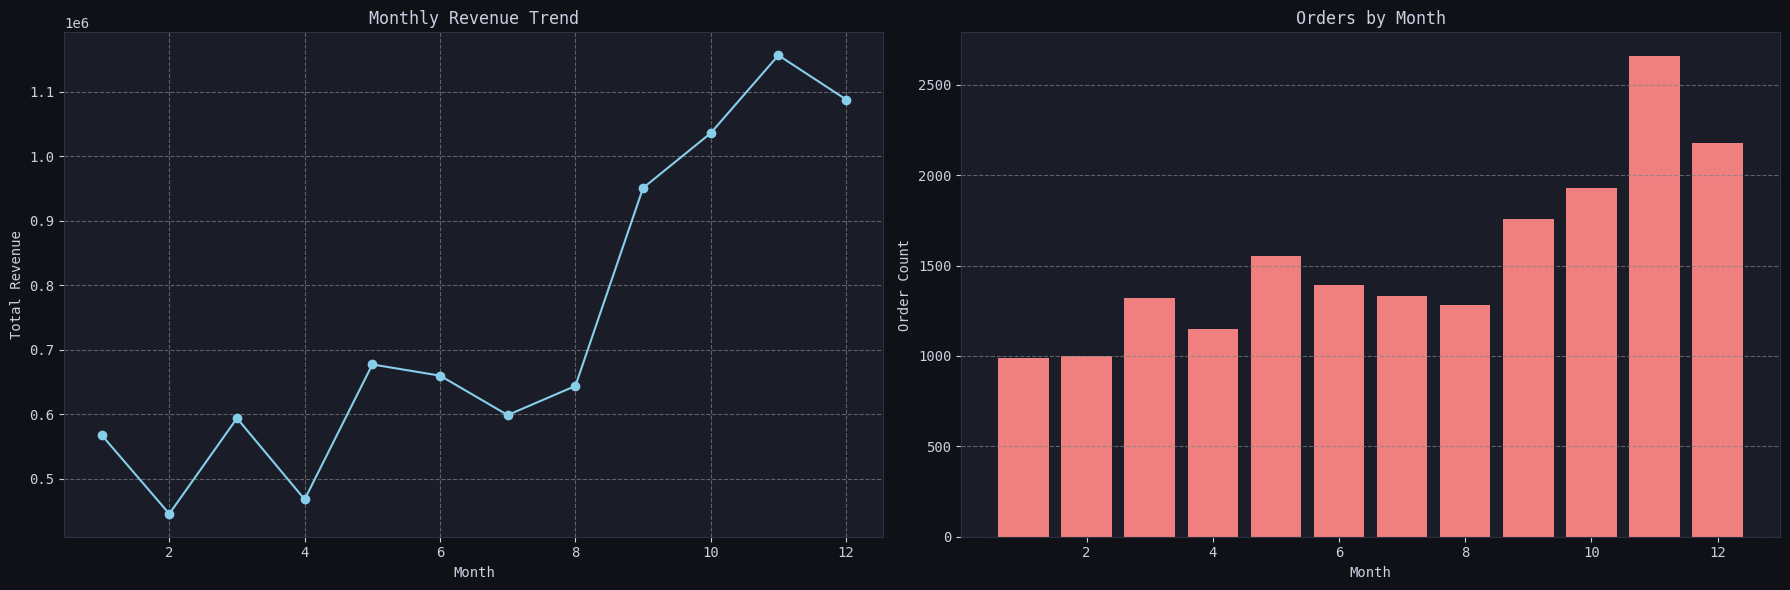

In [35]:
#line chart monthly revenue trend and  bar chart orders by month

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
#monthly revenue trend
axes[0].plot(monthly_revenue, marker='o', linestyle='-', color='skyblue')
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Revenue')
axes[0].grid(True, linestyle='--', alpha=0.7, color='gray')

#bar chart: Orders by month
axes[1].bar(monthly_order_count.index, monthly_order_count.values, color='lightcoral')

axes[1].set_title('Orders by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Order Count')
axes[1].grid(axis='y', linestyle='--', alpha=0.7, color='gray')

plt.tight_layout()
plt.show()

When is the business busiest? Any seasonal patterns?
* Based on the above plots, we can infer that, the business appears to be busiest towards the end of the year.
* There's a noticeable upward trend starting around September.
* November and December consistently show the highest Total Revenue and Order Count.


In [36]:
# ============================================================
# CHURN ANALYSIS
# ============================================================

# Step 1: Calculate last purchase date for each customer
customer_last_purchase = df.groupby('CustomerID')['InvoiceDate'].max()

# Step 2: Calculate days since last purchase
days_since_purchase = (reference_date - customer_last_purchase).dt.days

# Step 3: Define churn (90+ days inactive)
CHURN_THRESHOLD = 90
is_churned = days_since_purchase > CHURN_THRESHOLD

# Step 4: Create churn dataframe
churn_df = pd.DataFrame({
    'CustomerID': customer_last_purchase.index,
    'LastPurchaseDate': customer_last_purchase.values,
    'DaysSinceLastPurchase': days_since_purchase.values,
    'IsChurned': is_churned.values
})

# Step 5: Calculate statistics
churn_count = is_churned.sum()
total_customers = len(churn_df)
churn_rate = (churn_count / total_customers) * 100

print(f"Total Customers: {total_customers}")
print(f"Churned Customers: {churn_count}")
print(f"Churn Rate: {churn_rate:.2f}%")



Total Customers: 4339
Churned Customers: 1449
Churn Rate: 33.39%


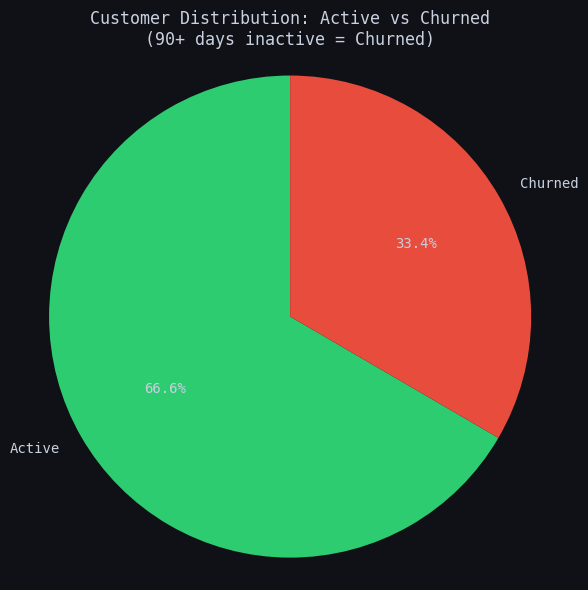

In [37]:
plt.figure(figsize=(6, 6))
churn_counts = churn_df['IsChurned'].value_counts()
labels = ['Active', 'Churned']
colors = ['#2ecc71', '#e74c3c']  # Green for active, red for churned
plt.pie(churn_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Customer Distribution: Active vs Churned\n(90+ days inactive = Churned)')
plt.axis('equal')
plt.tight_layout()
plt.show()



In [38]:
print("\n" + "="*80)
print("Churn by Segment")
print("="*80)

# Merge churn status with RFM segments
churn_with_segment = churn_df.merge(rfm[['Segment']], left_on='CustomerID', right_index=True)

# Calculate churn by segment
churn_by_segment = churn_with_segment.groupby('Segment').agg({
    'IsChurned': [
        ('Total_Customers', 'count'),
        ('Churned_Count', 'sum'),
        ('Active_Count', lambda x: (x == False).sum()),
        ('Churn_Rate_%', lambda x: (x.sum() / len(x)) * 100)
    ]
}).round(2)

# Flatten column names
churn_by_segment.columns = ['_'.join(col).strip() for col in churn_by_segment.columns.values]
churn_by_segment = churn_by_segment.reset_index()

print("\nChurn Rate by Customer Segment:")
print(churn_by_segment.to_string())

# Find highest churn segment
highest_churn_segment = churn_by_segment.loc[churn_by_segment['IsChurned_Churn_Rate_%'].idxmax()]
print(f"\n HIGHEST CHURN SEGMENT: {highest_churn_segment['Segment']}")
print(f"   Churn Rate: {highest_churn_segment['IsChurned_Churn_Rate_%']:.2f}%")
print(f"   Customers at Risk: {int(highest_churn_segment['IsChurned_Churned_Count'])}")



Churn by Segment

Churn Rate by Customer Segment:
           Segment  IsChurned_Total_Customers  IsChurned_Churned_Count  IsChurned_Active_Count  IsChurned_Churn_Rate_%
0          At Risk                       1231                      433                     798                   35.17
1        Champions                        930                        0                     930                    0.00
2   Lost Customers                       1377                     1016                     361                   73.78
3  Loyal Customers                        801                        0                     801                    0.00

 HIGHEST CHURN SEGMENT: Lost Customers
   Churn Rate: 73.78%
   Customers at Risk: 1016


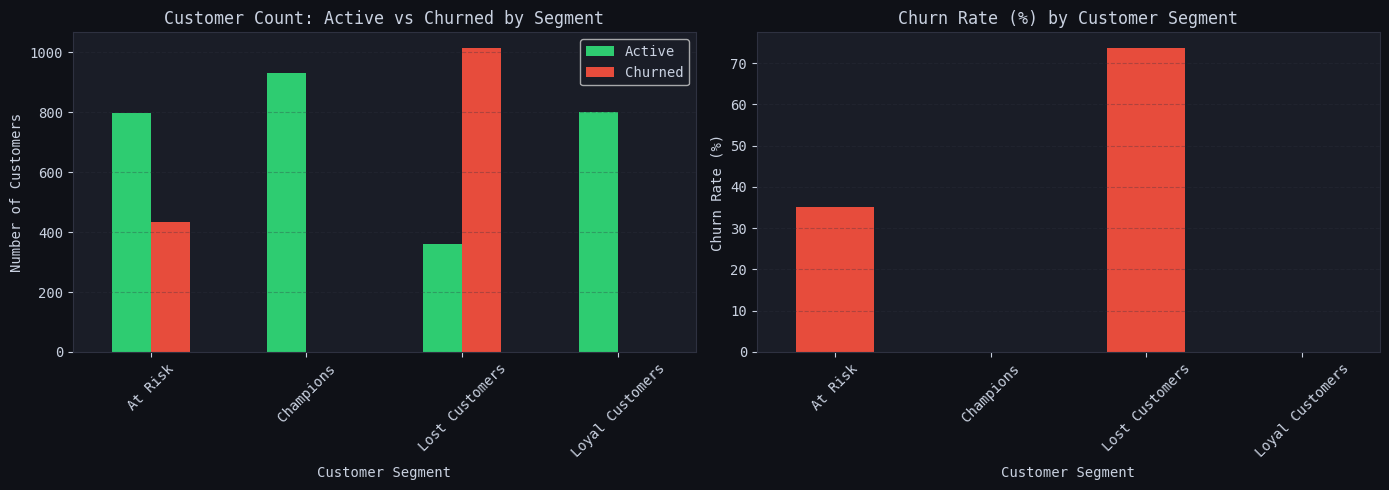

In [39]:
# Visualization 2: Bar chart - Churn rate by segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart 1: Churn count by segment
churn_summary = churn_with_segment.groupby('Segment')['IsChurned'].value_counts().unstack(fill_value=0)
churn_summary.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Customer Count: Active vs Churned by Segment')
axes[0].set_xlabel('Customer Segment')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(['Active', 'Churned'])
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Bar chart 2: Churn rate % by segment
churn_rate_by_segment = (churn_with_segment.groupby('Segment')['IsChurned'].sum() /
                         churn_with_segment.groupby('Segment').size() * 100)
churn_rate_by_segment.plot(kind='bar', ax=axes[1], color='#e74c3c')
axes[1].set_title('Churn Rate (%) by Customer Segment')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
print("\n" + "="*80)
print("Behavioral Differences")
print("="*80)

# Merge churn status with RFM to compare behaviors
churn_behavior = churn_df.merge(rfm[['Recency', 'Frequency', 'Monetary']],
                                left_on='CustomerID', right_index=True)

# Compare churned vs active customers
behavior_comparison = churn_behavior.groupby('IsChurned').agg({
    'DaysSinceLastPurchase': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
}).round(2)

# Flatten and rename columns
behavior_comparison.columns = ['_'.join(col).strip() for col in behavior_comparison.columns.values]
behavior_comparison.index = ['Active', 'Churned']

print("\nBehavioral Comparison: Churned vs Active Customers")
print(behavior_comparison)

# Key insights
churned_avg_spending = churn_behavior[churn_behavior['IsChurned']]['Monetary'].mean()
active_avg_spending = churn_behavior[~churn_behavior['IsChurned']]['Monetary'].mean()
spending_difference = ((active_avg_spending - churned_avg_spending) / churned_avg_spending * 100)

print(f"\n KEY INSIGHTS:")
print(f"   • Active customers spend {spending_difference:.1f}% MORE than churned customers")
print(f"   • Churned avg spending: £{churned_avg_spending:.2f}")
print(f"   • Active avg spending: £{active_avg_spending:.2f}")

churned_avg_frequency = churn_behavior[churn_behavior['IsChurned']]['Frequency'].mean()
active_avg_frequency = churn_behavior[~churn_behavior['IsChurned']]['Frequency'].mean()
frequency_difference = ((active_avg_frequency - churned_avg_frequency) / churned_avg_frequency * 100)

print(f"   • Active customers purchase {frequency_difference:.1f}% MORE frequently")
print(f"   • Churned avg frequency: {churned_avg_frequency:.1f} purchases")
print(f"   • Active avg frequency: {active_avg_frequency:.1f} purchases")


Behavioral Differences

Behavioral Comparison: Churned vs Active Customers
         DaysSinceLastPurchase_mean  DaysSinceLastPurchase_median  \
Active                        31.81                          25.0   
Churned                      213.61                         205.0   

         Frequency_mean  Frequency_median  Monetary_mean  Monetary_median  
Active           119.35              61.0        2717.88           984.74  
Churned           33.00              21.0         712.59           348.15  

 KEY INSIGHTS:
   • Active customers spend 281.4% MORE than churned customers
   • Churned avg spending: £712.59
   • Active avg spending: £2717.88
   • Active customers purchase 261.6% MORE frequently
   • Churned avg frequency: 33.0 purchases
   • Active avg frequency: 119.3 purchases


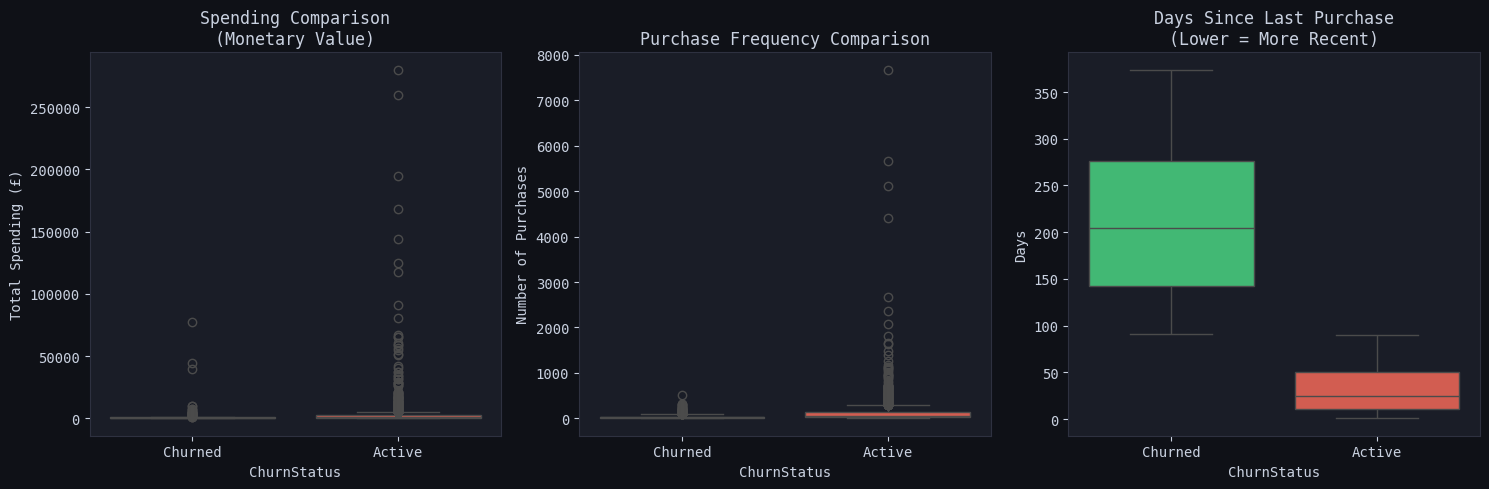

In [41]:
# Visualization 3: Box plots comparing behaviors
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Monetary comparison
churn_behavior['ChurnStatus'] = churn_behavior['IsChurned'].map({True: 'Churned', False: 'Active'})
sns.boxplot(data=churn_behavior, x='ChurnStatus', y='Monetary', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Spending Comparison\n(Monetary Value)')
axes[0].set_ylabel('Total Spending (£)')

# Frequency comparison
sns.boxplot(data=churn_behavior, x='ChurnStatus', y='Frequency', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Purchase Frequency Comparison')
axes[1].set_ylabel('Number of Purchases')

# Recency comparison
sns.boxplot(data=churn_behavior, x='ChurnStatus', y='DaysSinceLastPurchase', ax=axes[2], palette=['#2ecc71', '#e74c3c'])
axes[2].set_title('Days Since Last Purchase\n(Lower = More Recent)')
axes[2].set_ylabel('Days')

plt.tight_layout()
plt.show()

In [47]:

# At-Risk Customers & Recommendations

print("\n" + "="*80)
print("CHURN ANALYSIS: At-Risk Customers")
print("="*80)

# Identify high-value at-risk customers
# At-risk = no purchase in 90 days AND used to be a good customer (defined as high monetary value)
# A customer cannot be 'Champion' or 'Loyal' (by RFM definition) and also 'IsChurned'.
# Redefine 'high-value' as customers in the top 2 quintiles of Monetary value (M score >= 4)
high_value_customer_ids = rfm[rfm['M'].astype(int) >= 4].index

at_risk_high_value = churn_df[
    (churn_df['IsChurned']) &
    (churn_df['CustomerID'].isin(high_value_customer_ids))
].sort_values('DaysSinceLastPurchase', ascending=False)


print(f"\n HIGH-VALUE AT-RISK CUSTOMERS (formerly Champions/Loyal, now churned)")
print(f"Total: {len(at_risk_high_value)} customers")
print(f"\nTop 20 At-Risk High-Value Customers:")
print(at_risk_high_value.head(20).to_string())

# Calculate potential revenue from at-risk customers
# Merge with RFM to get monetary value
at_risk_with_value = at_risk_high_value.merge(
    rfm[['Monetary']],
    left_on='CustomerID',
    right_index=True
)

total_revenue_at_risk = at_risk_with_value['Monetary'].sum()
avg_revenue_per_atrisk = at_risk_with_value['Monetary'].mean()

print(f"\n REVENUE AT RISK:")
print(f"   • Total potential revenue from at-risk customers: £{total_revenue_at_risk:,.2f}")
print(f"   • Average revenue per at-risk customer: £{avg_revenue_per_atrisk:,.2f}")
print(f"   • If we retain 30%: £{total_revenue_at_risk * 0.3:,.2f}")
print(f"   • If we retain 50%: £{total_revenue_at_risk * 0.5:,.2f}")

# Segmentation of at-risk customers
at_risk_segment = churn_with_segment[churn_with_segment['IsChurned']]
at_risk_by_segment = at_risk_segment['Segment'].value_counts()

print(f"\n AT-RISK CUSTOMERS BY SEGMENT:")
for segment, count in at_risk_by_segment.items():
    pct = (count / len(at_risk_segment)) * 100
    print(f"   • {segment}: {count} customers ({pct:.1f}%)")



CHURN ANALYSIS: At-Risk Customers

 HIGH-VALUE AT-RISK CUSTOMERS (formerly Champions/Loyal, now churned)
Total: 243 customers

Top 20 At-Risk High-Value Customers:
      CustomerID    LastPurchaseDate  DaysSinceLastPurchase  IsChurned
4017     17850.0 2010-12-02 15:27:00                    372       True
3231     16754.0 2010-12-02 17:38:00                    372       True
2193     15332.0 2010-12-08 14:43:00                    366       True
478      12967.0 2010-12-16 19:10:00                    358       True
2881     16270.0 2010-12-21 14:26:00                    353       True
2290     15464.0 2011-01-05 15:56:00                    338       True
123      12501.0 2011-01-07 12:28:00                    337       True
3696     17406.0 2011-01-10 15:07:00                    333       True
2071     15171.0 2011-01-12 15:36:00                    331       True
0        12346.0 2011-01-18 10:01:00                    326       True
1534     14439.0 2011-01-24 11:39:00                  

In [51]:

# BUSINESS RECOMMENDATIONS BASED ON CHURN ANALYSIS

print("\n" + "="*80)
print("BUSINESS RECOMMENDATIONS")
print("="*80)

print(f"""
Based on the churn analysis, here are 5 actionable recommendations:

1. RE-ENGAGEMENT CAMPAIGN FOR AT-RISK HIGH-VALUE CUSTOMERS
   • Target: {len(at_risk_high_value)} customers with 90+ days inactivity
   • Potential revenue: £{total_revenue_at_risk:,.2f}
   • Action: Send personalized win-back offers (15-20% discount)
   • Expected outcome: If 30% return = £{total_revenue_at_risk * 0.3:,.2f} recovered revenue

2. RETENTION PROGRAM FOR CHAMPIONS & LOYAL CUSTOMERS
   • {len(rfm[rfm['Segment'] == 'Champions'])} Champions generate bulk of revenue
   • Action: Create VIP loyalty program with exclusive perks
   • Expected: Increase retention from {churn_rate_by_segment.get('Champions', 'N/A'):.0f}% to 85%+

3. INCREASE PURCHASE FREQUENCY FOR ONE-TIME BUYERS
   • {len(total_transactions[total_transactions['TotalTransactions'] == 1]) / len(total_transactions) * 100:.1f}% of customers buy only once
   • Action: Automated email series at 14, 30, 60 days post-purchase
   • Expected: Convert 10-15% of one-time buyers to repeat customers

4. SEASONALITY OPTIMIZATION
   • Peak season: November-December (plan inventory accordingly)
   • Off-peak: January-June (run promotional campaigns)
   • Action: Stock up before September, run flash sales in slow months

5. EARLY WARNING SYSTEM
   • Implement monitoring: Customers with no purchase in 60+ days
   • Action: Automated gentle reminder at 60 days, discount offer at 75 days
   • Expected: Reduce churn rate by 15-20%


""")

print("="*80)


BUSINESS RECOMMENDATIONS

Based on the churn analysis, here are 5 actionable recommendations:

1. RE-ENGAGEMENT CAMPAIGN FOR AT-RISK HIGH-VALUE CUSTOMERS
   • Target: 243 customers with 90+ days inactivity
   • Potential revenue: £619,115.12
   • Action: Send personalized win-back offers (15-20% discount)
   • Expected outcome: If 30% return = £185,734.54 recovered revenue

2. RETENTION PROGRAM FOR CHAMPIONS & LOYAL CUSTOMERS
   • 930 Champions generate bulk of revenue
   • Action: Create VIP loyalty program with exclusive perks
   • Expected: Increase retention from 0% to 85%+

3. INCREASE PURCHASE FREQUENCY FOR ONE-TIME BUYERS
   • 34.4% of customers buy only once
   • Action: Automated email series at 14, 30, 60 days post-purchase
   • Expected: Convert 10-15% of one-time buyers to repeat customers

4. SEASONALITY OPTIMIZATION
   • Peak season: November-December (plan inventory accordingly)
   • Off-peak: January-June (run promotional campaigns)
   • Action: Stock up before Septemb

In [44]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.colors

# Create subplots
fig = make_subplots(rows=2, cols=2,
                    subplot_titles=("Distribution of RFM Scores", "Customer Count Per Segment",
                                    "Churn Rate (%) by Customer Segment", "Top 10 Products by Revenue"))

# Plot 1: Distribution of RFM Scores
fig.add_trace(go.Bar(x=rfm_score_counts.index, y=rfm_score_counts.values,
                     marker_color=plotly.colors.sequential.Viridis, name='RFM Scores'),
              row=1, col=1)
fig.update_xaxes(title_text='RFM Score', row=1, col=1)
fig.update_yaxes(title_text='Number of Customers', row=1, col=1)

# Plot 2: Customer Count Per Segment
fig.add_trace(go.Bar(x=segment_stats['Segment'], y=segment_stats['Customer_Count'],
                     marker_color=plotly.colors.sequential.Viridis, name='Customer Count'),
              row=1, col=2)
fig.update_xaxes(title_text='Segment', row=1, col=2)
fig.update_yaxes(title_text='Number of Customers', row=1, col=2)

# Plot 3: Churn Rate (%) by Customer Segment
# Ensure segment_stats includes IsChurned_Churn_Rate_%
# Merge churn_by_segment with segment_stats to get churn rates
churn_rate_df = churn_by_segment[['Segment', 'IsChurned_Churn_Rate_%']].rename(columns={'IsChurned_Churn_Rate_%': 'Churn_Rate'})

fig.add_trace(go.Bar(x=churn_rate_df['Segment'], y=churn_rate_df['Churn_Rate'],
                     marker_color='#e74c3c', name='Churn Rate'),
              row=2, col=1)
fig.update_xaxes(title_text='Customer Segment', row=2, col=1)
fig.update_yaxes(title_text='Churn Rate (%)', row=2, col=1)

# Plot 4: Top 10 Products by Revenue
fig.add_trace(go.Bar(x=top_10_pdts['TotalRevenue'], y=top_10_pdts['Description'],
                     orientation='h', marker_color=plotly.colors.sequential.Viridis, name='Revenue'),
              row=2, col=2)
fig.update_xaxes(title_text='Total Revenue (£)', row=2, col=2)
fig.update_yaxes(title_text='Product Description', row=2, col=2)

# Update layout
fig.update_layout(title_text='Key Business Insights Dashboard', title_x=0.5,
                  height=800, showlegend=False)

fig.show()
